# What Distinguishes Early Trajectories of Single-State vs Multi-State Outcomes?

We identified 36 receptors where replicate simulations of the **same protein** produce
different labels (some single-state, some multi-state). These are the ideal test cases:
same sequence, same structure, different outcomes.

This analysis asks: **what is different in the early trajectory segments** between
replicates that end up single-state vs multi-state?

We compare:
1. Per-frame pairwise distance matrices (which residue-residue distances differ?)
2. Per-frame feature distributions (RMSD, Rg, etc.)
3. Temporal dynamics (variance, autocorrelation patterns)

If differences are found, they suggest which features future work should target.
If no differences are found, it confirms that early trajectory segments are truly
indistinguishable regardless of future outcome.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Paths
METADATA_CSV = "../data/metadata/metadata.csv"
CA_COORD_DIR = Path("../../gcs_mount/data/ca_coords")
SCALAR_DIR = Path("../../gcs_mount/data/processed/v4/features_50pct/scalar")
GRAPH_DIR = Path("../../gcs_mount/data/processed/graph_embeddings")
STRUCTURAL_DIR = Path("../../gcs_mount/data/processed/structural_embeddings")
RESULTS_DIR = Path("results/disagreement_analysis")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EARLY_FRAC = 0.5
SKIP_EQ = 100  # equilibration frames to skip

## Step 1: Identify Disagreeing Receptors

In [2]:
df = pd.read_csv(METADATA_CSV)
print(f"Total trajectories: {len(df)}")

# Find receptors with multiple trajectories and mixed labels
receptor_stats = df.groupby('receptor').agg(
    n_traj=('y', 'count'),
    n_multi=('y', 'sum'),
    n_single=('y', lambda x: (x == 0).sum()),
).reset_index()

receptor_stats['has_both'] = (receptor_stats['n_multi'] > 0) & (receptor_stats['n_single'] > 0)
disagreeing = receptor_stats[receptor_stats['has_both']].copy()

print(f"Receptors with multiple trajectories: {(receptor_stats['n_traj'] > 1).sum()}")
print(f"Receptors with MIXED labels: {len(disagreeing)}")
print(f"\nDisagreeing receptors:")
disagreeing.sort_values('n_traj', ascending=False)

Total trajectories: 247
Receptors with multiple trajectories: 69
Receptors with MIXED labels: 36

Disagreeing receptors:


,receptor,n_traj,n_multi,n_single,has_both
140,unknown~3W5A,5,1.0,4,True
35,Beta-1_adrenergic_receptor~5A8E_A,4,1.0,3,True
25,Beta-1_adrenergic_receptor~2Y00_B,4,1.0,3,True
33,Beta-1_adrenergic_receptor~4AMJ_B,4,2.0,2,True
137,Type-1_angiotensin_II_receptor~4ZUD_A,4,3.0,1,True
27,Beta-1_adrenergic_receptor~2Y03_B,4,1.0,3,True
51,C-C_chemokine_receptor_type_5~4MBS_A,3,1.0,2,True
52,C-X-C_chemokine_receptor_type_4~3ODU_A,3,1.0,2,True
117,P2Y_purinoceptor_1~4XNV_A,3,1.0,2,True
118,P2Y_purinoceptor_1~4XNW_A,3,1.0,2,True


## Step 2: Helper Functions

In [3]:
def find_npy(receptor, rep, simID, npy_dir, patterns=None):
    """Find NPY file for a trajectory, trying multiple naming conventions."""
    npy_dir = Path(npy_dir)
    receptor_clean = str(receptor).replace('~', '_')
    rep = int(float(rep))
    simID = int(float(simID))
    candidates = [
        f"{receptor_clean}_rep{rep}_{simID}.npy",
        f"{receptor_clean}_sim{simID}_rep{rep}.npy",
        f"early_ts_{receptor_clean}_rep{rep}_{simID}.npy",
    ]
    for name in candidates:
        p = npy_dir / name
        if p.exists():
            return p
    return None


def kabsch_align(mobile, reference):
    """Kabsch alignment of mobile to reference. Both (n_atoms, 3)."""
    mobile_c = mobile - mobile.mean(axis=0)
    ref_c = reference - reference.mean(axis=0)
    H = mobile_c.T @ ref_c
    V, _, Wt = np.linalg.svd(H)
    if np.linalg.det(V @ Wt) < 0:
        V[:, -1] *= -1
    R = V @ Wt
    return mobile_c @ R


def compute_pairwise_dist_summary(ca_coords, skip_eq=100, frac=0.5):
    """
    Compute mean pairwise distance matrix from early trajectory segment.
    ca_coords: (n_frames, n_residues, 3)
    Returns: (n_residues, n_residues) mean distance matrix
    """
    n_frames = ca_coords.shape[0]
    start = min(skip_eq, n_frames - 1)
    n_use = max(1, int((n_frames - start) * frac))
    frames = ca_coords[start:start + n_use]

    # Align to first frame
    ref = frames[0].astype(np.float64)
    aligned = np.zeros_like(frames, dtype=np.float64)
    for i in range(len(frames)):
        aligned[i] = kabsch_align(frames[i].astype(np.float64), ref)

    # Compute per-frame pairwise distance matrices, then average
    n_res = aligned.shape[1]
    dist_sum = np.zeros((n_res, n_res))
    for i in range(len(aligned)):
        dists = squareform(pdist(aligned[i]))
        dist_sum += dists
    dist_mean = dist_sum / len(aligned)

    return dist_mean, aligned


def compute_dynamics_features(aligned_frames):
    """
    Compute per-residue dynamics features from aligned early trajectory.
    aligned_frames: (n_frames, n_residues, 3)
    Returns dict of per-residue features.
    """
    n_frames, n_res, _ = aligned_frames.shape

    # RMSF per residue
    mean_pos = aligned_frames.mean(axis=0)  # (n_res, 3)
    rmsf = np.sqrt(((aligned_frames - mean_pos) ** 2).sum(axis=2).mean(axis=0))  # (n_res,)

    # Per-residue displacement between consecutive frames
    displacements = np.sqrt(((aligned_frames[1:] - aligned_frames[:-1]) ** 2).sum(axis=2))  # (n_frames-1, n_res)
    disp_mean = displacements.mean(axis=0)  # (n_res,)
    disp_std = displacements.std(axis=0)    # (n_res,)

    # Per-residue autocorrelation (lag-1) of position
    autocorr = np.zeros(n_res)
    for r in range(n_res):
        # Autocorrelation of the distance-from-mean time series
        dist_from_mean = np.sqrt(((aligned_frames[:, r, :] - mean_pos[r]) ** 2).sum(axis=1))
        if dist_from_mean.std() > 1e-10:
            autocorr[r] = np.corrcoef(dist_from_mean[:-1], dist_from_mean[1:])[0, 1]

    return {
        'rmsf': rmsf,
        'disp_mean': disp_mean,
        'disp_std': disp_std,
        'autocorr': autocorr,
    }

## Step 3: Within-Receptor Comparison

For each disagreeing receptor, compare the early trajectory segments
of single-state vs multi-state replicates.

In [4]:
# Analyze each disagreeing receptor
receptor_comparisons = []
residue_level_diffs = []  # for aggregation across receptors

for receptor in disagreeing['receptor'].values:
    rec_df = df[df['receptor'] == receptor]
    single_trajs = rec_df[rec_df['y'] == 0]
    multi_trajs = rec_df[rec_df['y'] == 1]

    # Load CA coords for each replicate
    single_data = []
    multi_data = []

    for _, row in single_trajs.iterrows():
        path = find_npy(row['receptor'], row['rep'], row['simID'], CA_COORD_DIR)
        if path:
            single_data.append(np.load(path))

    for _, row in multi_trajs.iterrows():
        path = find_npy(row['receptor'], row['rep'], row['simID'], CA_COORD_DIR)
        if path:
            multi_data.append(np.load(path))

    if not single_data or not multi_data:
        continue

    # All replicates should have the same n_residues
    n_res = single_data[0].shape[1]
    if any(d.shape[1] != n_res for d in single_data + multi_data):
        continue

    # Compute dynamics features for early segments of each replicate
    single_features = []
    multi_features = []

    for coords in single_data:
        _, aligned = compute_pairwise_dist_summary(coords, SKIP_EQ, EARLY_FRAC)
        single_features.append(compute_dynamics_features(aligned))

    for coords in multi_data:
        _, aligned = compute_pairwise_dist_summary(coords, SKIP_EQ, EARLY_FRAC)
        multi_features.append(compute_dynamics_features(aligned))

    # Compare per-residue features between single and multi replicates
    for feature_name in ['rmsf', 'disp_mean', 'disp_std', 'autocorr']:
        single_vals = np.array([f[feature_name] for f in single_features])  # (n_single, n_res)
        multi_vals = np.array([f[feature_name] for f in multi_features])    # (n_multi, n_res)

        single_mean = single_vals.mean(axis=0)  # (n_res,)
        multi_mean = multi_vals.mean(axis=0)     # (n_res,)

        # Normalized difference per residue
        denom = np.maximum(0.5 * (np.abs(single_mean) + np.abs(multi_mean)), 1e-10)
        norm_diff = (multi_mean - single_mean) / denom  # (n_res,)

        # Store relative position (0-1) to allow cross-protein comparison
        rel_positions = np.arange(n_res) / n_res

        for i in range(n_res):
            residue_level_diffs.append({
                'receptor': receptor,
                'feature': feature_name,
                'residue_idx': i,
                'rel_position': rel_positions[i],
                'norm_diff': norm_diff[i],
                'single_mean': single_mean[i],
                'multi_mean': multi_mean[i],
            })

    # Compute pairwise distance differences
    single_dists = [compute_pairwise_dist_summary(c, SKIP_EQ, EARLY_FRAC)[0] for c in single_data]
    multi_dists = [compute_pairwise_dist_summary(c, SKIP_EQ, EARLY_FRAC)[0] for c in multi_data]

    single_dist_mean = np.mean(single_dists, axis=0)
    multi_dist_mean = np.mean(multi_dists, axis=0)
    dist_diff = np.abs(multi_dist_mean - single_dist_mean)

    # Top differing residue pairs
    upper_tri = np.triu_indices(n_res, k=1)
    diffs_flat = dist_diff[upper_tri]
    top_idx = np.argsort(diffs_flat)[-10:][::-1]

    receptor_comparisons.append({
        'receptor': receptor,
        'n_residues': n_res,
        'n_single': len(single_data),
        'n_multi': len(multi_data),
        'mean_dist_diff': float(diffs_flat.mean()),
        'max_dist_diff': float(diffs_flat.max()),
        'median_dist_diff': float(np.median(diffs_flat)),
        'top_pairs': [(int(upper_tri[0][i]), int(upper_tri[1][i]), float(diffs_flat[i]))
                      for i in top_idx],
    })

print(f"Analyzed {len(receptor_comparisons)} disagreeing receptors")
comp_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'top_pairs'}
                         for r in receptor_comparisons])
comp_df.sort_values('max_dist_diff', ascending=False).head(15)

Analyzed 31 disagreeing receptors


,receptor,n_residues,n_single,n_multi,mean_dist_diff,max_dist_diff,median_dist_diff
11,Beta-arrestin-2~6K3F,373,1,1,1.495596,37.939985,0.639148
20,Muscarinic_acetylcholine_receptor_M2~4MQS_A,296,1,1,1.422958,23.554459,0.605283
16,Free_fatty_acid_receptor_1~4PHU_A,294,1,1,1.195180,21.692341,0.508357
9,Beta-2_adrenergic_receptor~4LDO_A,303,1,1,1.064768,21.409773,0.542441
8,Beta-2_adrenergic_receptor~3NYA_A,303,1,1,1.102613,20.618182,0.458015
0,5-hydroxytryptamine_receptor_2B~4IB4_A,306,1,1,0.884082,16.855629,0.453549
15,Delta-type_opioid_receptor~4N6H_A,303,1,1,0.988316,16.229092,0.354495
4,Adenosine_receptor_A2a~3UZC_A,313,1,1,1.144547,15.951811,0.732282
1,ADRB2~3NYA_A,303,1,1,0.950019,15.435568,0.387023
29,Type-1_angiotensin_II_receptor~4ZUD_A,309,1,3,1.209006,15.274345,0.571174


## Step 4: Aggregate Residue-Level Differences Across Proteins

Using relative residue position (0-1) to align across proteins of different lengths.
Are there consistent **regions** of the protein where early dynamics differ between
single-state and multi-state outcomes?

Total residue-level comparisons: 40520


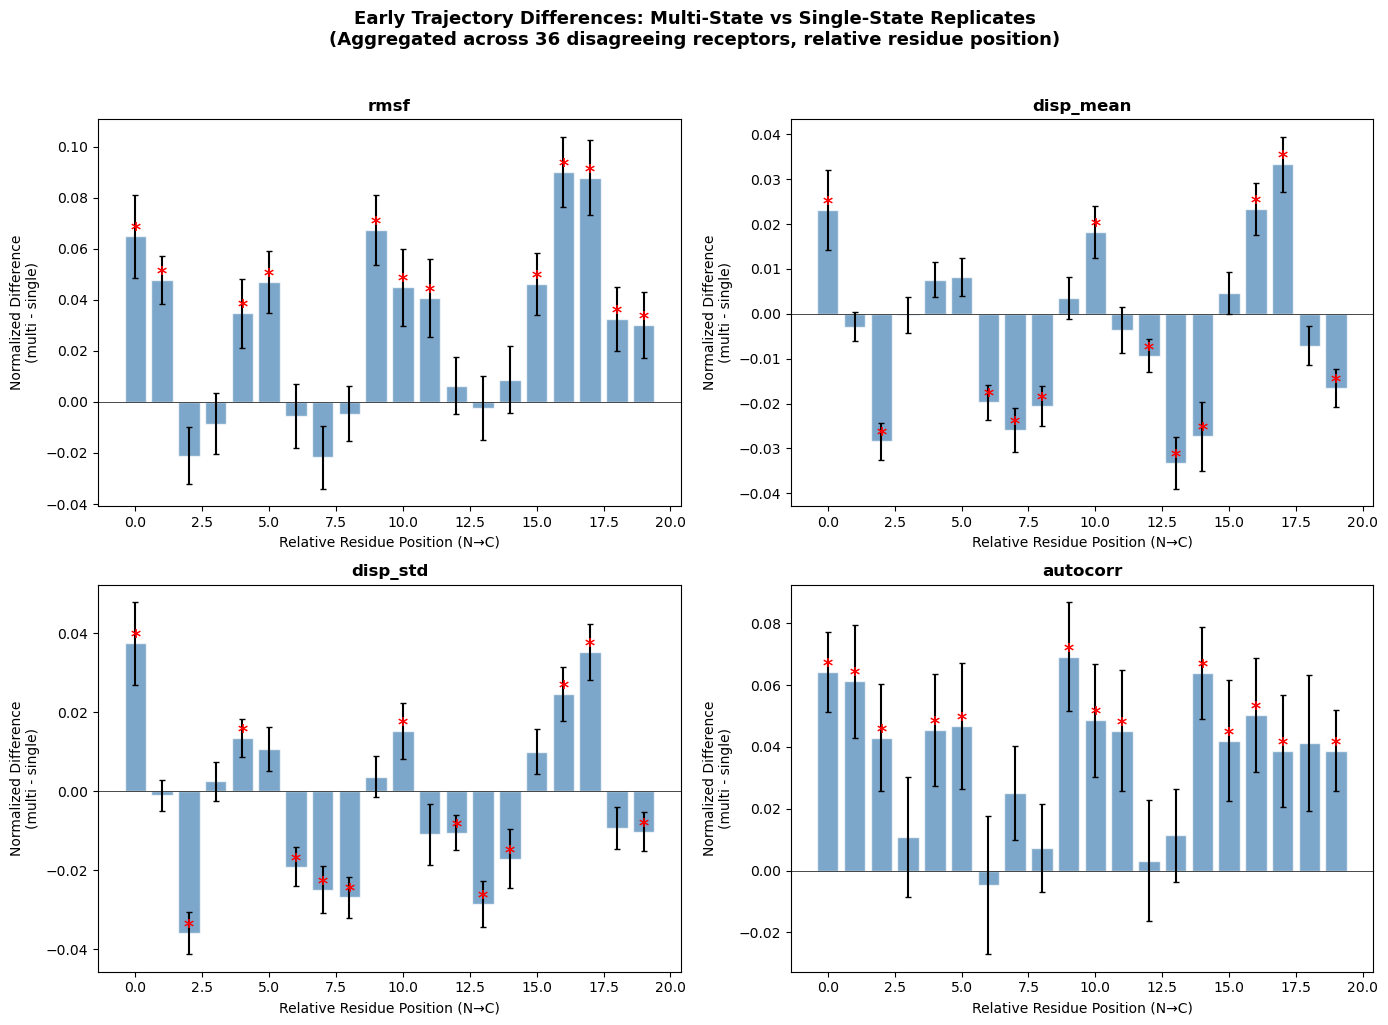

In [5]:
diff_df = pd.DataFrame(residue_level_diffs)
print(f"Total residue-level comparisons: {len(diff_df)}")

# Bin relative positions into ~20 segments
diff_df['position_bin'] = pd.cut(diff_df['rel_position'], bins=20, labels=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flat, ['rmsf', 'disp_mean', 'disp_std', 'autocorr']):
    feat_df = diff_df[diff_df['feature'] == feature]

    # Mean normalized difference per position bin across all receptors
    binned = feat_df.groupby('position_bin')['norm_diff'].agg(['mean', 'std', 'count']).reset_index()
    binned['se'] = binned['std'] / np.sqrt(binned['count'])

    ax.bar(binned['position_bin'], binned['mean'],
           yerr=binned['se'], color='steelblue', alpha=0.7,
           capsize=2, edgecolor='white')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xlabel('Relative Residue Position (N→C)', fontsize=10)
    ax.set_ylabel('Normalized Difference\n(multi - single)', fontsize=10)
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold')

    # Highlight if any bin is significantly different from 0
    for _, row in binned.iterrows():
        if abs(row['mean']) > 2 * row['se'] and row['count'] > 10:
            ax.annotate('*', (row['position_bin'], row['mean']),
                       ha='center', fontsize=14, fontweight='bold', color='red')

plt.suptitle('Early Trajectory Differences: Multi-State vs Single-State Replicates\n'
             '(Aggregated across 36 disagreeing receptors, relative residue position)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'residue_level_differences.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Statistical test: for each feature and position bin, is the mean difference
# significantly different from zero?
print("Significant position bins (|mean| > 2*SE, n > 10):")
print(f"{'Feature':<15s} {'Bin':>4s} {'Mean Diff':>10s} {'SE':>8s} {'N':>5s} {'Position':>10s}")
print("-" * 55)

n_significant = 0
for feature in ['rmsf', 'disp_mean', 'disp_std', 'autocorr']:
    feat_df = diff_df[diff_df['feature'] == feature]
    binned = feat_df.groupby('position_bin')['norm_diff'].agg(['mean', 'std', 'count']).reset_index()
    binned['se'] = binned['std'] / np.sqrt(binned['count'])

    for _, row in binned.iterrows():
        if abs(row['mean']) > 2 * row['se'] and row['count'] > 10:
            pos_start = row['position_bin'] / 20
            pos_end = (row['position_bin'] + 1) / 20
            print(f"{feature:<15s} {int(row['position_bin']):>4d} {row['mean']:>10.4f} "
                  f"{row['se']:>8.4f} {int(row['count']):>5d} {pos_start:.2f}-{pos_end:.2f}")
            n_significant += 1

if n_significant == 0:
    print("  None — early trajectory dynamics are indistinguishable between outcomes.")
else:
    print(f"\n  {n_significant} significant bins found.")

Significant position bins (|mean| > 2*SE, n > 10):
Feature          Bin  Mean Diff       SE     N   Position
-------------------------------------------------------
rmsf               0     0.0649   0.0161   523 0.00-0.05
rmsf               1     0.0478   0.0094   507 0.05-0.10
rmsf               4     0.0348   0.0136   507 0.20-0.25
rmsf               5     0.0470   0.0123   503 0.25-0.30
rmsf               9     0.0674   0.0137   506 0.45-0.50
rmsf              10     0.0449   0.0150   506 0.50-0.55
rmsf              11     0.0407   0.0153   507 0.55-0.60
rmsf              15     0.0463   0.0122   502 0.75-0.80
rmsf              16     0.0901   0.0138   504 0.80-0.85
rmsf              17     0.0879   0.0147   508 0.85-0.90
rmsf              18     0.0326   0.0126   505 0.90-0.95
rmsf              19     0.0302   0.0129   500 0.95-1.00
disp_mean          0     0.0232   0.0090   523 0.00-0.05
disp_mean          2    -0.0284   0.0041   503 0.10-0.15
disp_mean          6    -0.0197   0.0

## Step 5: Pairwise Distance Difference Analysis

For the top disagreeing receptors, visualize which residue-residue contacts
differ most between single-state and multi-state early trajectories.

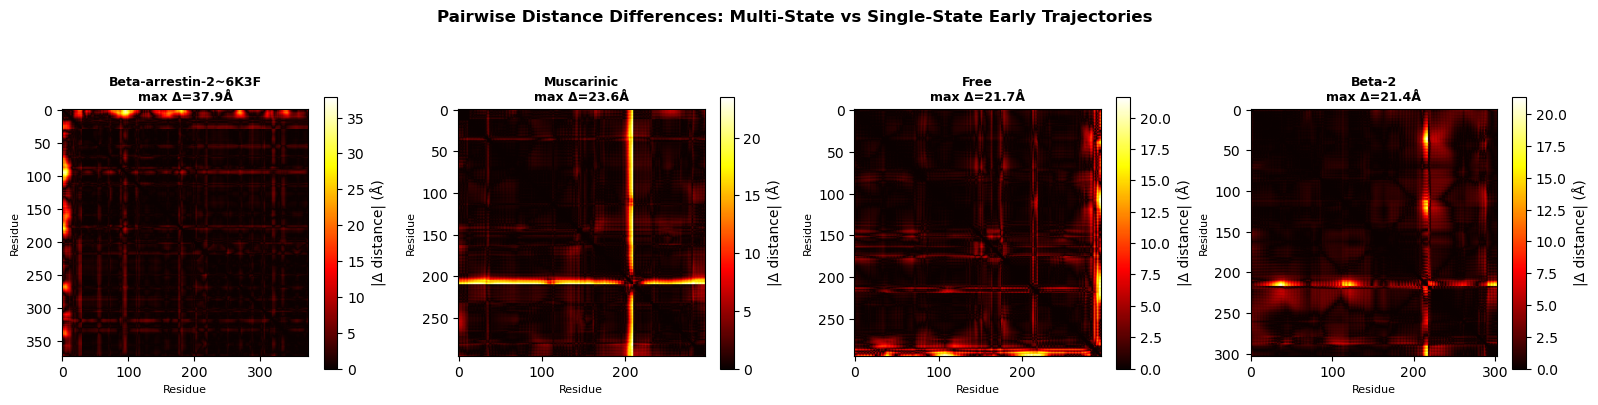

In [7]:
# Show distance difference maps for top 4 receptors
top_receptors = comp_df.sort_values('max_dist_diff', ascending=False).head(4)

fig, axes = plt.subplots(1, min(4, len(top_receptors)), figsize=(16, 4))
if len(top_receptors) == 1:
    axes = [axes]

for ax, (_, rec_row) in zip(axes, top_receptors.iterrows()):
    receptor = rec_row['receptor']
    rec_comp = [r for r in receptor_comparisons if r['receptor'] == receptor][0]

    # Recompute distance maps for visualization
    rec_df_sub = df[df['receptor'] == receptor]
    single_trajs = rec_df_sub[rec_df_sub['y'] == 0]
    multi_trajs = rec_df_sub[rec_df_sub['y'] == 1]

    single_dists = []
    for _, row in single_trajs.iterrows():
        path = find_npy(row['receptor'], row['rep'], row['simID'], CA_COORD_DIR)
        if path:
            d, _ = compute_pairwise_dist_summary(np.load(path), SKIP_EQ, EARLY_FRAC)
            single_dists.append(d)

    multi_dists_list = []
    for _, row in multi_trajs.iterrows():
        path = find_npy(row['receptor'], row['rep'], row['simID'], CA_COORD_DIR)
        if path:
            d, _ = compute_pairwise_dist_summary(np.load(path), SKIP_EQ, EARLY_FRAC)
            multi_dists_list.append(d)

    if single_dists and multi_dists_list:
        diff_map = np.abs(np.mean(multi_dists_list, axis=0) - np.mean(single_dists, axis=0))
        im = ax.imshow(diff_map, cmap='hot', aspect='equal')
        plt.colorbar(im, ax=ax, shrink=0.8, label='|Δ distance| (Å)')

    short_name = receptor.replace('~', ' ').split('_')[0] if len(receptor) > 25 else receptor
    ax.set_title(f"{short_name}\nmax Δ={rec_row['max_dist_diff']:.1f}Å",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Residue', fontsize=8)
    ax.set_ylabel('Residue', fontsize=8)

plt.suptitle('Pairwise Distance Differences: Multi-State vs Single-State Early Trajectories',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'distance_difference_maps.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Overall Distribution Comparison

Across all disagreeing receptors, how large are the early trajectory differences
relative to the within-class variability?

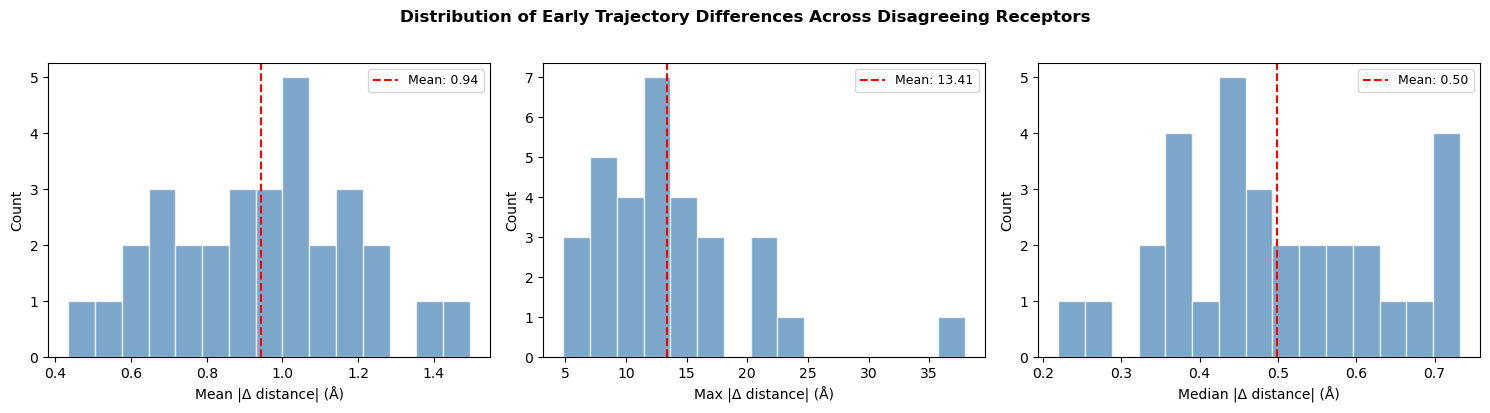


Summary across 31 disagreeing receptors:
  Mean |Δ distance|:   0.944 ± 0.260 Å
  Max  |Δ distance|:   13.405 ± 6.634 Å
  Median |Δ distance|: 0.498 ± 0.139 Å


In [8]:
# Distribution of max pairwise distance differences
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, label in [
    (axes[0], 'mean_dist_diff', 'Mean |Δ distance| (Å)'),
    (axes[1], 'max_dist_diff', 'Max |Δ distance| (Å)'),
    (axes[2], 'median_dist_diff', 'Median |Δ distance| (Å)'),
]:
    vals = comp_df[metric].values
    ax.hist(vals, bins=15, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(np.mean(vals), color='red', linestyle='--', label=f'Mean: {np.mean(vals):.2f}')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Early Trajectory Differences Across Disagreeing Receptors',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'distance_diff_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSummary across {len(comp_df)} disagreeing receptors:")
print(f"  Mean |Δ distance|:   {comp_df['mean_dist_diff'].mean():.3f} ± {comp_df['mean_dist_diff'].std():.3f} Å")
print(f"  Max  |Δ distance|:   {comp_df['max_dist_diff'].mean():.3f} ± {comp_df['max_dist_diff'].std():.3f} Å")
print(f"  Median |Δ distance|: {comp_df['median_dist_diff'].mean():.3f} ± {comp_df['median_dist_diff'].std():.3f} Å")

In [9]:
# Save results
comp_df.to_csv(RESULTS_DIR / 'receptor_comparisons.csv', index=False)
diff_df.to_csv(RESULTS_DIR / 'residue_level_diffs.csv', index=False)
print(f"Saved: {RESULTS_DIR / 'receptor_comparisons.csv'}")
print(f"Saved: {RESULTS_DIR / 'residue_level_diffs.csv'}")

Saved: results/disagreement_analysis/receptor_comparisons.csv
Saved: results/disagreement_analysis/residue_level_diffs.csv


## Interpretation

**If differences are small and non-systematic:**
Early trajectory segments of single-state and multi-state replicates are statistically
indistinguishable. The future outcome is determined by stochastic events that occur
*after* the early segment, confirming that early prediction is fundamentally limited.

**If differences are localized to specific regions:**
Specific residue pairs or protein regions show early-segment differences that correlate
with future outcome. This suggests that targeted features (e.g., specific inter-helical
distances in GPCRs) might enable prediction, pointing to concrete future work.

**If differences are large but inconsistent across receptors:**
Each protein has unique early signatures, which explains why cross-protein generalization
fails — the predictive features are protein-specific, not universal.